# 🤟 ASL Sign Language Translation Engine

### Classical Machine Learning vs. Neural Networks

**Project Goal:**  
Build a translation engine that takes a static image of an American Sign
Language (ASL) hand sign and predicts the corresponding letter.

This project compares two machine learning approaches:

- **Control Model:** Random Forest
- **Experimental Model:** Multi-Layer Perceptron (MLP)

The models are trained and evaluated using the Sign Language MNIST dataset.
The strongest model will then be deployed as an interactive application.

---

### Project Pipeline

**Dataset → Preprocessing → Random Forest → MLP Experiments → Model Comparison → Deployment**

## 📋 Project Requirements

The project is divided into three stages:

### Week 1 — Classical Machine Learning
Train a Random Forest baseline model and evaluate it using a confusion matrix.

### Week 2 — Neural Network Experiments
Build Multi-Layer Perceptron neural networks using PyTorch and compare
different architectures and activation functions. Track experiments using
Weights & Biases.

### Week 3 — Deployment
Deploy the strongest model in an application that accepts a PNG image of
an ASL hand sign and returns the predicted letter and confidence score.

> **Constraint:** Pre-trained models are not used in this project.

# 1. Environment Setup

This section imports the libraries required for data processing,
visualization, classical machine learning, neural networks, and
experiment tracking.

In [1]:
# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Classical machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Model saving
import joblib

# Experiment tracking
import wandb

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 2. Dataset

The project uses the **Sign Language MNIST** dataset.

Each example is a **28 × 28 grayscale image** of an ASL hand sign.
After flattening the image, each sample contains **784 pixel features**.

The dataset contains 24 static ASL letter classes.

In [3]:
train_path = "/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train.csv"
test_path = "/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

train_df.head()

Training data: (27455, 785)
Testing data: (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


### Dataset Structure

The `label` column represents the correct ASL class.

The remaining 784 columns contain grayscale pixel values ranging from
0 to 255.

# 3. Exploratory Data Analysis

Before training the models, several samples are visualized to verify
that the image data and labels were loaded correctly.

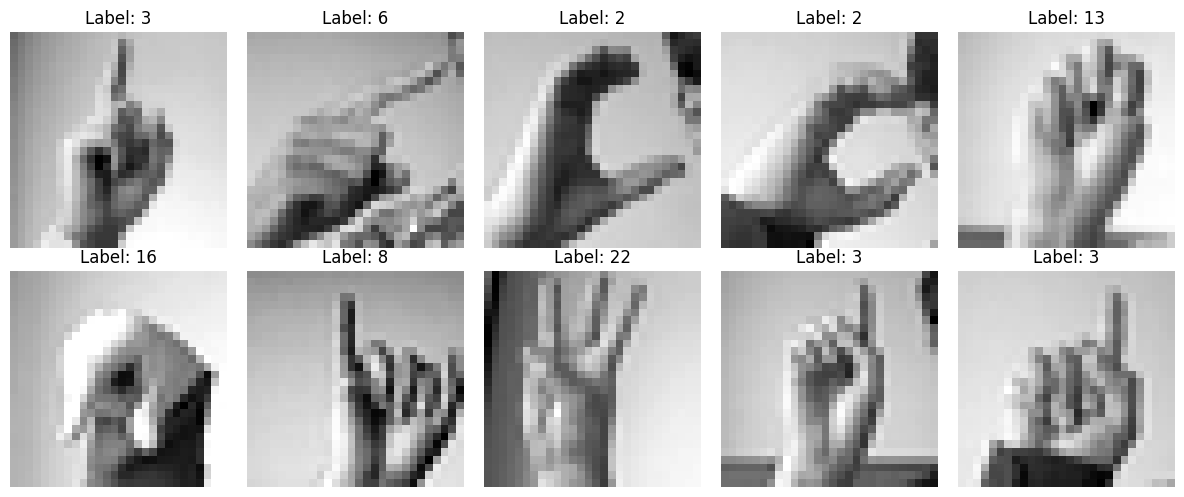

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):

    image = train_df.drop("label", axis=1).iloc[i].values.reshape(28, 28)
    label = train_df["label"].iloc[i]

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# 4. Data Preprocessing

Before model training:

1. The `label` column is separated from the image pixels.
2. Pixel values are normalized from **0–255** to **0–1**.
3. The same train/test split supplied by the dataset is maintained for
   consistent comparison between models.

In [5]:
X_train = train_df.drop("label", axis=1)
y_train = train_df["label"]

X_test = test_df.drop("label", axis=1)
y_test = test_df["label"]

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (27455, 784)
Testing features: (7172, 784)


---

# 🌲 Week 1 — Classical Machine Learning Control

## Random Forest

The Random Forest classifier serves as the **control model**.

Its performance establishes a classical machine-learning baseline that
will later be compared against the neural network experiments.

## 5.1 Model Training

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


## 5.2 Model Evaluation

In [8]:
rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Test Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Test Accuracy: 81.64%


### Classification Report

Precision, recall, and F1-score provide additional information about
performance across individual ASL classes.

In [9]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95       331
           1       0.98      0.93      0.95       432
           2       0.94      1.00      0.97       310
           3       0.83      0.98      0.90       245
           4       0.87      0.99      0.93       498
           5       0.93      0.91      0.92       247
           6       0.93      0.86      0.89       348
           7       0.99      0.94      0.96       436
           8       0.83      0.80      0.81       288
          10       0.72      0.64      0.68       331
          11       0.82      1.00      0.90       209
          12       0.88      0.71      0.78       394
          13       0.75      0.52      0.61       291
          14       0.99      0.88      0.93       246
          15       0.92      1.00      0.96       347
          16       0.91      0.99      0.95       164
          17       0.29      0.55      0.38       144
          18       0.61    

## 5.3 Confusion Matrix

The confusion matrix shows which ASL classes the Random Forest
classified correctly and which classes were most frequently confused.

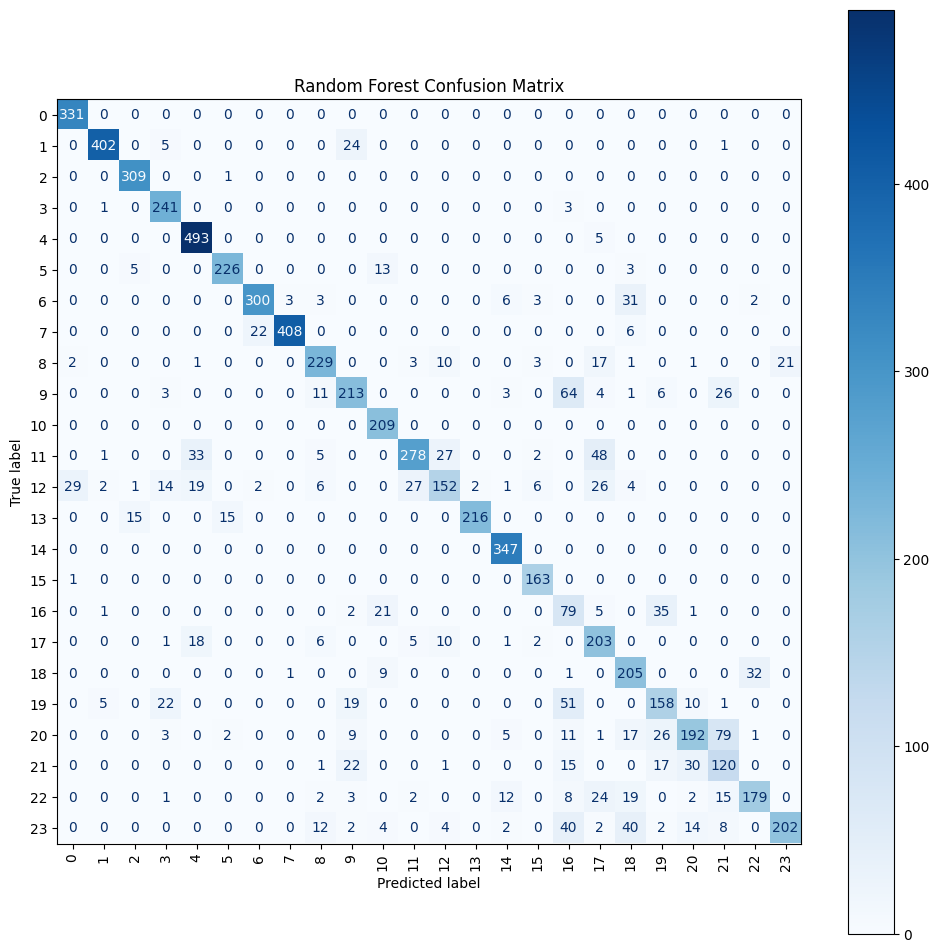

In [10]:
cm = confusion_matrix(y_test, rf_predictions)

fig, ax = plt.subplots(figsize=(12, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90
)

plt.title("Random Forest Confusion Matrix")
plt.show()

## 📊 Week 1 Results

The Random Forest achieved approximately **82% test accuracy**.

The classification report produced:

- **Accuracy:** 0.82
- **Macro-average F1:** 0.80
- **Weighted-average F1:** 0.82

These results establish the baseline that will be compared against the
MLP neural network experiments in Week 2.

## 8.3 Model Training

The model is trained for 10 epochs using batches of 64 images.
Training loss and accuracy are recorded after each epoch and sent
to W&B for experiment tracking.

In [18]:
# Train Experiment 1

epochs = 10

for epoch in range(epochs):

    model_1.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Move batch to GPU/CPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients from previous step
        optimizer_1.zero_grad()

        # Forward pass
        outputs = model_1(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer_1.step()

        # Track loss
        total_loss += loss.item()

        # Determine predicted classes
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate results for this epoch
    average_loss = total_loss / len(train_loader)
    training_accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Accuracy: {training_accuracy:.4f}"
    )

    # Send results to W&B
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": average_loss,
        "train_accuracy": training_accuracy
    })

Epoch 1/10 | Loss: 2.5303 | Accuracy: 0.2665
Epoch 2/10 | Loss: 1.6447 | Accuracy: 0.5136
Epoch 3/10 | Loss: 1.3004 | Accuracy: 0.6142
Epoch 4/10 | Loss: 1.1022 | Accuracy: 0.6696
Epoch 5/10 | Loss: 0.9651 | Accuracy: 0.7121
Epoch 6/10 | Loss: 0.8576 | Accuracy: 0.7458
Epoch 7/10 | Loss: 0.7768 | Accuracy: 0.7699
Epoch 8/10 | Loss: 0.6983 | Accuracy: 0.7973
Epoch 9/10 | Loss: 0.6392 | Accuracy: 0.8193
Epoch 10/10 | Loss: 0.5878 | Accuracy: 0.8332


## 8.4 Experiment 1 Evaluation

After training, the model is evaluated using the test dataset.
These images were not used to update the model during training,
making test accuracy a better measure of how well the model
generalizes to unseen data.

In [19]:
# Evaluate Experiment 1

model_1.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Make predictions
        outputs = model_1(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


# Calculate test accuracy
test_accuracy_1 = correct / total

print(
    f"Experiment 1 Test Accuracy: "
    f"{test_accuracy_1 * 100:.2f}%"
)

# Save final result to W&B
wandb.log({
    "test_accuracy": test_accuracy_1
})

# Finish this W&B run
wandb.finish()

Experiment 1 Test Accuracy: 65.10%


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁
train_accuracy,▁▄▅▆▇▇▇███
train_loss,█▅▄▃▂▂▂▁▁▁
epoch,10
test_accuracy,0.651
train_accuracy,0.83318
train_loss,0.58777


### Experiment 1 Results

**Architecture:** 784 → 128 → 24  
**Activation Function:** ReLU  
**Epochs:** 10  
**Batch Size:** 64  
**Learning Rate:** 0.001  
**Test Accuracy:** approximately 66.72%

Experiment 1 establishes the initial neural-network baseline.
The next experiment increases the size and depth of the network
to determine whether a more complex architecture improves
classification performance.